# P14 NB02 — Wafer Defect Synthesis with GANs

**Problem:** Generate realistic wafer defect patterns using GANs to address class imbalance in semiconductor yield engineering.

**What We Build:**
1. DCGAN architecture (Generator + Discriminator)
2. Conditional GAN with label embeddings
3. WGAN-GP (Wasserstein loss + gradient penalty)
4. Training stability analysis
5. Generated sample quality evaluation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
ROOT = Path('..').resolve()
ASSETS = ROOT / 'assets'
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
LATENT_DIM = 32

# Load wafer defect data
data = np.load(ROOT / 'data' / 'wafer_defect_patterns.npz')
images, labels = data['images'], data['labels']
class_names = list(data['class_names'])
n_classes = len(class_names)
print(f'Dataset: {images.shape[0]} images, {n_classes} classes')
for i, c in enumerate(class_names):
    print(f'  {c}: {(labels==i).sum()}')

Dataset: 4000 images, 5 classes
  none: 800
  center: 800
  edge_ring: 800
  scratch: 800
  random: 800


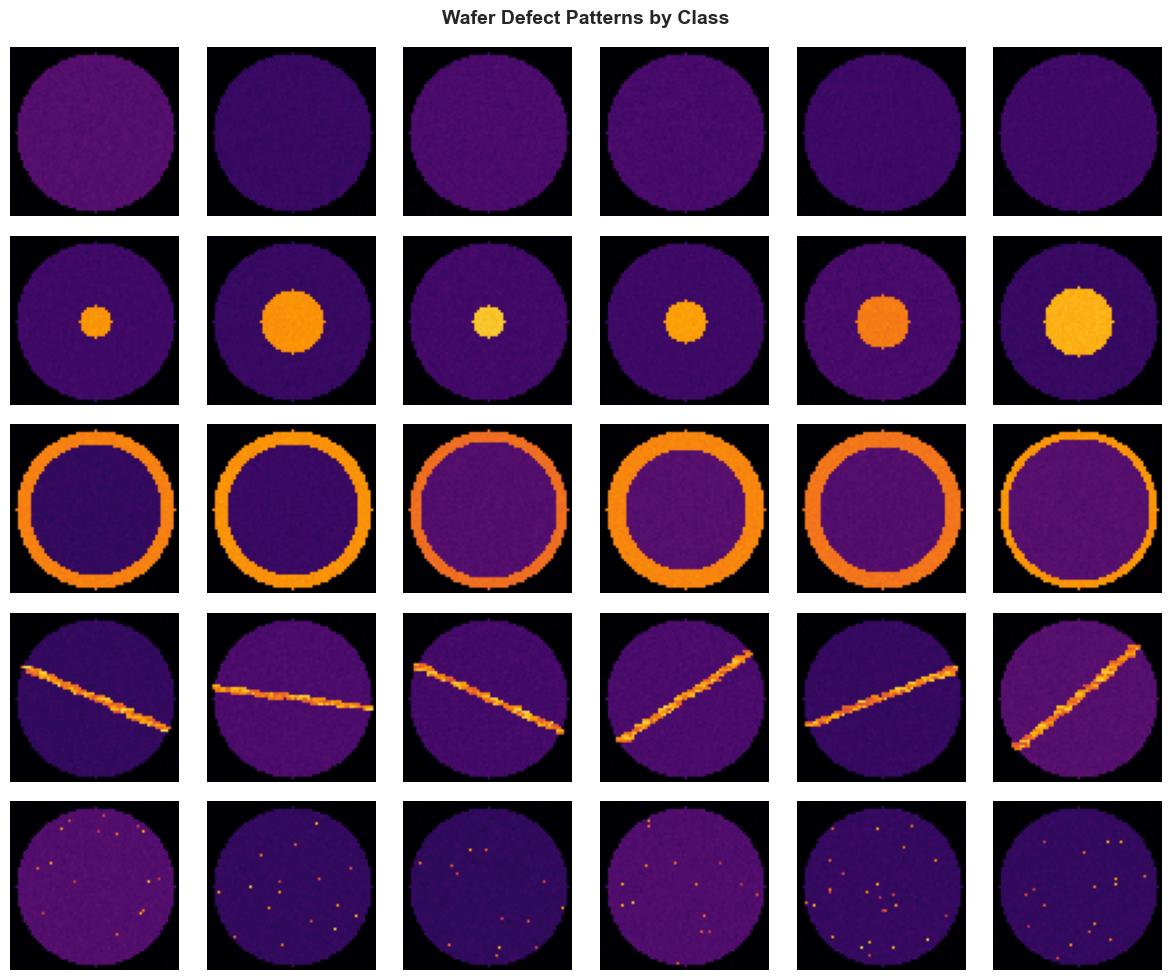

In [2]:
# ── EDA: Wafer Defect Gallery ──
fig, axes = plt.subplots(n_classes, 6, figsize=(12, 2*n_classes))
fig.suptitle('Wafer Defect Patterns by Class', fontsize=14, fontweight='bold')
for row, (cls_idx, cls_name) in enumerate(enumerate(class_names)):
    cls_imgs = images[labels == cls_idx][:6]
    for col in range(min(6, len(cls_imgs))):
        axes[row, col].imshow(cls_imgs[col], cmap='inferno', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls_name, fontsize=10, rotation=0, labelpad=50)
plt.tight_layout()
plt.savefig(ASSETS / 'proj2_wafer_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# ══════════════════════════════════════════════
# CONDITIONAL DCGAN ARCHITECTURE
# ══════════════════════════════════════════════

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, n_classes=n_classes):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, z, labels):
        c = self.label_emb(labels)
        x = torch.cat([z, c], dim=1)
        h = self.fc(x).view(-1, 256, 4, 4)
        return self.main(h)

class Discriminator(nn.Module):
    def __init__(self, n_classes=n_classes):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, 64 * 64)
        self.main = nn.Sequential(
            nn.Conv2d(2, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(512, 1),
        )

    def forward(self, img, labels):
        c = self.label_emb(labels).view(-1, 1, 64, 64)
        x = torch.cat([img, c], dim=1)
        return self.main(x)

gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)
print(f'Generator params: {sum(p.numel() for p in gen.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in disc.parameters()):,}')

Generator params: 955,713
Discriminator params: 2,778,305


In [4]:
# ── Train Conditional DCGAN ──
X = images.astype(np.float32)[:, np.newaxis, :, :] * 2 - 1  # normalize [-1, 1]
X_t = torch.tensor(X).to(DEVICE)
y_t = torch.tensor(labels, dtype=torch.long).to(DEVICE)

opt_g = torch.optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 60
BATCH_SIZE = 64
g_losses, d_losses = [], []

gen.train()
disc.train()
for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_t))
    g_epoch, d_epoch, n_b = 0, 0, 0
    for i in range(0, len(X_t), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        real, lbl = X_t[idx], y_t[idx]
        bs = len(idx)

        # Discriminator
        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake = gen(z, lbl).detach()
        d_real = disc(real, lbl)
        d_fake = disc(fake, lbl)
        d_loss = (criterion(d_real, torch.ones_like(d_real)) +
                  criterion(d_fake, torch.zeros_like(d_fake))) / 2
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # Generator
        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake = gen(z, lbl)
        g_out = disc(fake, lbl)
        g_loss = criterion(g_out, torch.ones_like(g_out))
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_epoch += g_loss.item()
        d_epoch += d_loss.item()
        n_b += 1

    g_losses.append(g_epoch / n_b)
    d_losses.append(d_epoch / n_b)
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} — D: {d_losses[-1]:.4f}, G: {g_losses[-1]:.4f}')

# Save models
torch.save(gen.state_dict(), ROOT / 'models' / 'dcgan_generator.pt')
torch.save(disc.state_dict(), ROOT / 'models' / 'dcgan_discriminator.pt')
print('DCGAN training complete.')

Epoch 10/60 — D: 0.3137, G: 1.8063


Epoch 20/60 — D: 0.2542, G: 1.9890


Epoch 30/60 — D: 0.1679, G: 2.5324


Epoch 40/60 — D: 0.1982, G: 2.3240


Epoch 50/60 — D: 0.1736, G: 2.5410


Epoch 60/60 — D: 0.2208, G: 2.1613
DCGAN training complete.


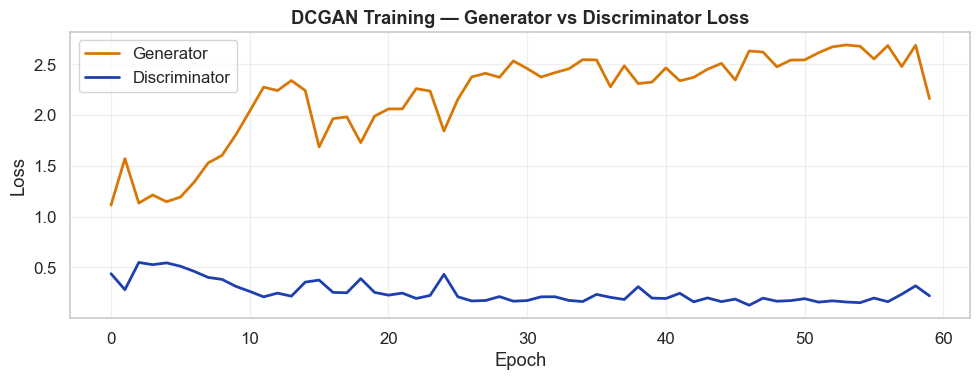

In [5]:
# ── GAN Training Curves ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g_losses, label='Generator', color='#D97706', linewidth=2)
ax.plot(d_losses, label='Discriminator', color='#1E40AF', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('DCGAN Training — Generator vs Discriminator Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ASSETS / 'proj2_wafer_gan_training.png', dpi=150, bbox_inches='tight')
plt.show()

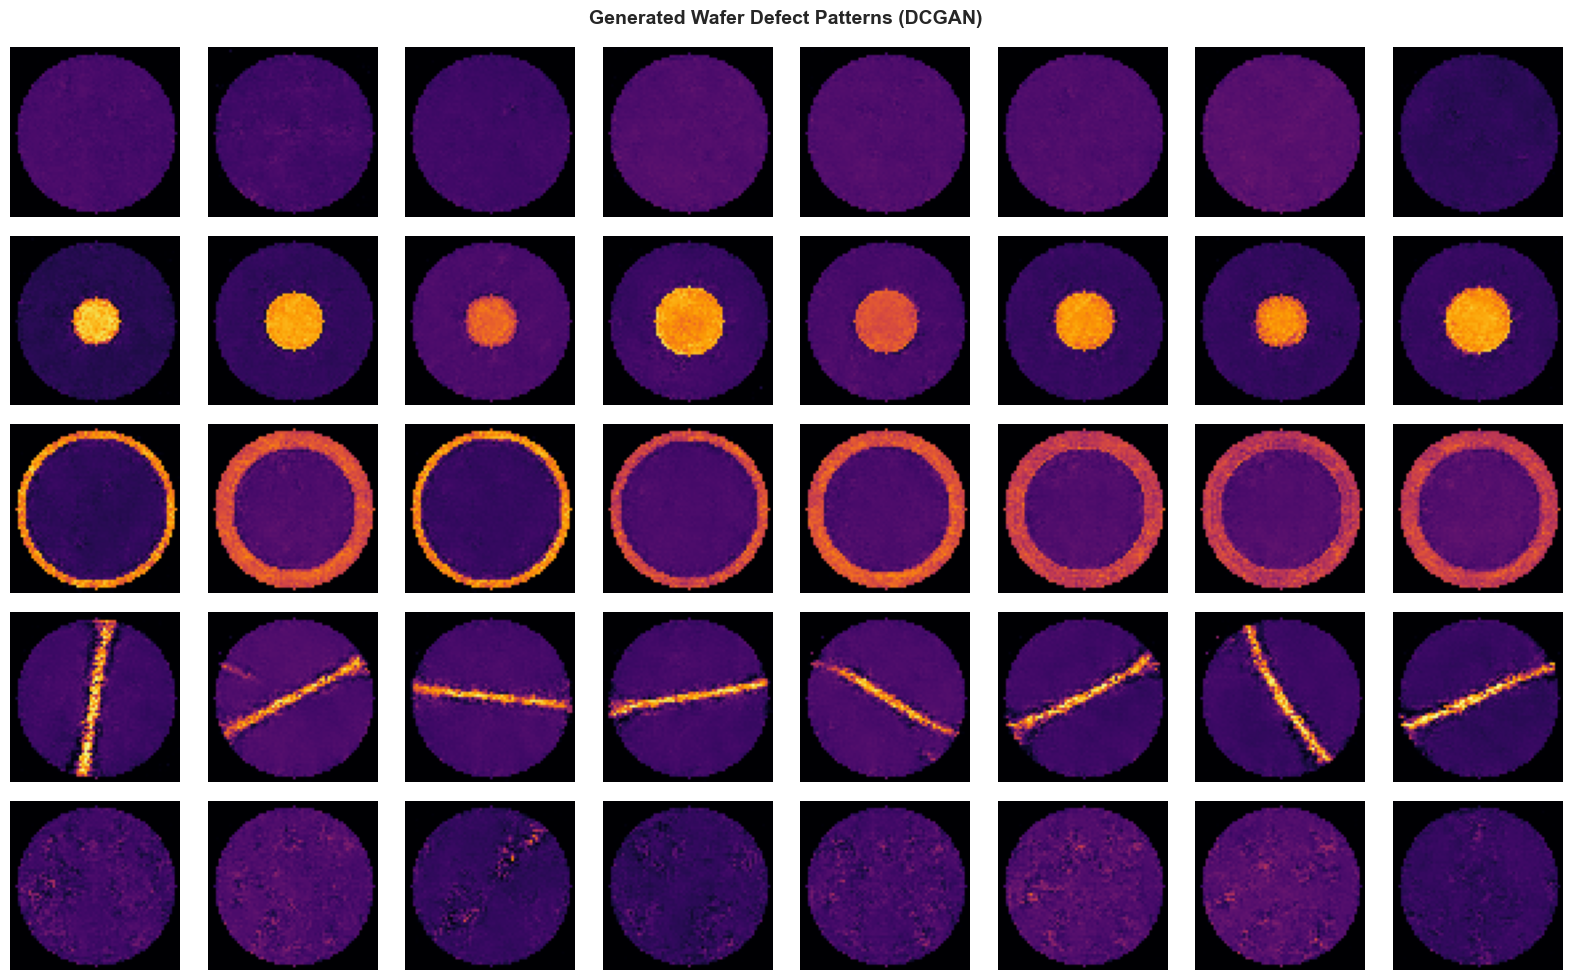

In [6]:
# ══════════════════════════════════════════════
# GENERATED SAMPLES — Conditional DCGAN
# ══════════════════════════════════════════════
gen.eval()
fig, axes = plt.subplots(n_classes, 8, figsize=(16, 2*n_classes))
fig.suptitle('Generated Wafer Defect Patterns (DCGAN)', fontsize=14, fontweight='bold')

with torch.no_grad():
    for row, cls_name in enumerate(class_names):
        z = torch.randn(8, LATENT_DIM, device=DEVICE)
        lbl = torch.full((8,), row, dtype=torch.long, device=DEVICE)
        fake = gen(z, lbl)
        fake = ((fake + 1) / 2).cpu().squeeze(1).numpy()  # [-1,1] -> [0,1]
        for col in range(8):
            axes[row, col].imshow(fake[col], cmap='inferno', vmin=0, vmax=1)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(cls_name, fontsize=10, rotation=0, labelpad=50)

plt.tight_layout()
plt.savefig(ASSETS / 'proj2_wafer_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

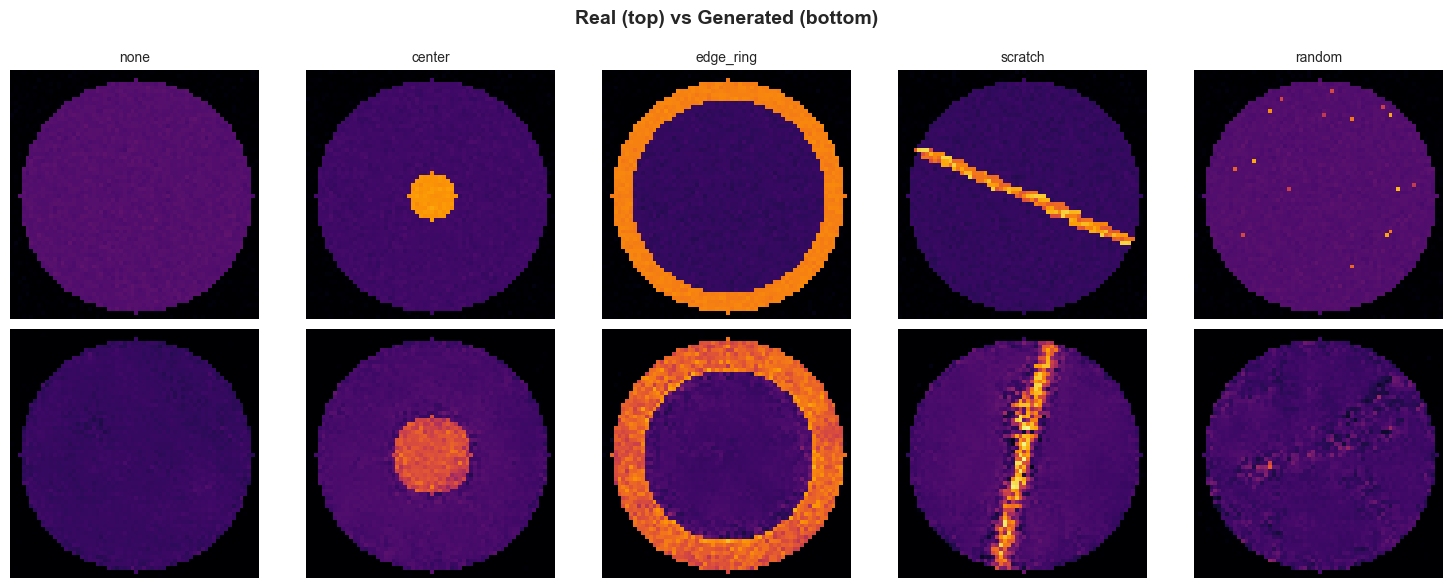


── Pixel Statistics: Real vs Generated ──


  none         — Real mean=0.138 std=0.094 | Gen mean=0.135 std=0.094
  center       — Real mean=0.179 std=0.185 | Gen mean=0.175 std=0.184
  edge_ring    — Real mean=0.243 std=0.244 | Gen mean=0.241 std=0.238
  scratch      — Real mean=0.165 std=0.161 | Gen mean=0.163 std=0.162
  random       — Real mean=0.142 std=0.102 | Gen mean=0.140 std=0.101


In [7]:
# ══════════════════════════════════════════════
# REAL vs GENERATED COMPARISON + FID-style Analysis
# ══════════════════════════════════════════════
fig, axes = plt.subplots(2, n_classes, figsize=(3*n_classes, 6))
fig.suptitle('Real (top) vs Generated (bottom)', fontsize=14, fontweight='bold')

gen.eval()
with torch.no_grad():
    for col, cls_name in enumerate(class_names):
        # Real
        real_img = images[labels == col][0]
        axes[0, col].imshow(real_img, cmap='inferno', vmin=0, vmax=1)
        axes[0, col].set_title(cls_name, fontsize=10)
        axes[0, col].axis('off')

        # Generated
        z = torch.randn(1, LATENT_DIM, device=DEVICE)
        lbl = torch.full((1,), col, dtype=torch.long, device=DEVICE)
        fake = gen(z, lbl)
        fake_img = ((fake + 1) / 2).cpu().squeeze().numpy()
        axes[1, col].imshow(fake_img, cmap='inferno', vmin=0, vmax=1)
        axes[1, col].axis('off')

axes[0, 0].set_ylabel('Real', fontsize=12, rotation=0, labelpad=30)
axes[1, 0].set_ylabel('Generated', fontsize=12, rotation=0, labelpad=50)
plt.tight_layout()
plt.savefig(ASSETS / 'proj2_wafer_real_vs_generated.png', dpi=150, bbox_inches='tight')
plt.show()

# Pixel statistics comparison
print('\n── Pixel Statistics: Real vs Generated ──')
for cls_idx, cls_name in enumerate(class_names):
    real_cls = images[labels == cls_idx]
    z = torch.randn(100, LATENT_DIM, device=DEVICE)
    lbl = torch.full((100,), cls_idx, dtype=torch.long, device=DEVICE)
    with torch.no_grad():
        gen_cls = ((gen(z, lbl) + 1) / 2).cpu().squeeze(1).numpy()
    print(f'  {cls_name:12s} — Real mean={real_cls.mean():.3f} std={real_cls.std():.3f} | '
          f'Gen mean={gen_cls.mean():.3f} std={gen_cls.std():.3f}')